# BiCV sparsity sweep — Cousteau
Evaluates all trained models in `results/Cousteau/bi-cross-validation-sparsity/` using `evaluate_trial_average_MLP` and reproduces the R² vs λ_s scatter plot.

In [1]:
import os, importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import io

os.environ.setdefault("TORCHDYNAMO_DISABLE", "1")

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA
from msca.evaluations import evaluate_trial_average_MLP

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load data

In [2]:
def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs   = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
    return data_array, start_idxs, end_idxs

def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    data_downsamp = data_array[::downsample_factor]
    start_idxs = start_idxs // downsample_factor
    end_idxs   = end_idxs   // downsample_factor
    data_concat = data_downsamp.T
    fr_range = np.ptp(data_concat, axis=1)[:, None]
    data_norm = data_concat / (fr_range + 5)
    data_snm  = data_norm - np.mean(data_norm, axis=1)[:, None]
    return [np.copy(data_snm.T)[i:j] for i, j in zip(start_idxs, end_idxs)]

fp = "./data/"
m1_data,  m1_start,  m1_end  = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
sma_data, sma_start, sma_end = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

X = {
    "M1":  preprocess(m1_data,  m1_start,  m1_end),
    "SMA": preprocess(sma_data, sma_start, sma_end),
}
print(f"M1: {len(X['M1'])} trials, {X['M1'][0].shape[1]} neurons")
print(f"SMA: {len(X['SMA'])} trials, {X['SMA'][0].shape[1]} neurons")

M1: 20 trials, 116 neurons
SMA: 20 trials, 77 neurons


## 2. Config
λ values and directory names match exactly what `bi-cross-validation.py` produced.

In [3]:
BASE = "./results/Cousteau/bi-cross-validation-sparsity"
N_FOLDS = 5

# λ values in the sweep — must match the directory names under sweep/
LAM_VALUES = [0.001, 0.01, 0.1, 1, 1.5, 2, 2.5, 5, 10, 15, 20, 30, 40]

# Shared mSCA kwargs for loading (lam_sparse overridden per condition)
MSCA_BASE_KWARGS = dict(
    n_components        = 40,
    n_epochs            = 5000,
    linear              = False,
    loss_func           = "Gaussian",
    lam_orthog          = 0.1,
    lam_region          = 0.0,
    decoder_type        = "nonlinear",
    decoder_hidden_size = 40,
    sparsity_warmup_epochs = 0,
    decoder_activation  = "tanh",
    post_hoc_epoch      = -1,
    cd_rate             = 0.5,
    cd_mode             = "both",
    filter_len          = 41,
    init                = "unique",
    decoder_init_mode   = "pca",
)

## 3. Evaluation helper

In [4]:
def evaluate_condition(model_dir, splits_dir, lam_sparse, verbose=True):
    """
    For each of the 5 neuron-folds:
      - load msca_split_{i}.pt
      - call evaluate_trial_average_MLP(msca, X_train, X_val, n_splits=5)
      - average the 5 returned time-fold R² values → one scalar per neuron-fold
    Returns list of 5 fold-mean R² values.
    """
    train_idxs = torch.load(os.path.join(splits_dir, "n_train_splits.pt"), weights_only=False)
    test_idxs  = torch.load(os.path.join(splits_dir, "n_test_splits.pt"),  weights_only=False)

    fold_means = []
    for i in range(N_FOLDS):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            if verbose:
                print(f"  [skip] {model_path} not found")
            continue

        X_train = {k: [trial[:, train_idxs[k][i]] for trial in v] for k, v in X.items()}
        X_val   = {k: [trial[:, test_idxs[k][i]]  for trial in v] for k, v in X.items()}

        model = mSCA(**MSCA_BASE_KWARGS, lam_sparse=lam_sparse)
        model.load(model_path, X_train)

        # Returns list of 5 R² values (one per time-fold)
        r2_time_folds = evaluate_trial_average_MLP(model, X_train, X_val, n_splits=5)
        fold_mean = float(np.mean(r2_time_folds))
        fold_means.append(fold_mean)

        if verbose:
            print(f"  fold {i}: R²={fold_mean:.4f}")

    return fold_means

## 4. Run evaluation

In [5]:
# ── Baselines ──────────────────────────────────────────────────────────────
print("=== adaptive ===")
adaptive_r2 = evaluate_condition(
    model_dir  = os.path.join(BASE, "adaptive"),
    splits_dir = os.path.join(BASE, "adaptive"),
    lam_sparse = "adaptive",
)
print(f"  mean={np.mean(adaptive_r2):.4f}\n")

print("=== no_sparsity ===")
no_sparse_r2 = evaluate_condition(
    model_dir  = os.path.join(BASE, "no_sparsity"),
    splits_dir = os.path.join(BASE, "no_sparsity"),
    lam_sparse = 0.0,
)
print(f"  mean={np.mean(no_sparse_r2):.4f}")

=== adaptive ===
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = adaptive
Using lam_orthog = 23.759950912818965
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 0: R²=0.8042
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = adaptive
Using lam_orthog = 24.620536978894616
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 1: R²=0.8177
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = adaptive
Using lam_orthog = 23.97254373430498
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 2: R²=0.8143
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = adaptive
Using lam_orthog = 23.909526854389323
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden 

In [6]:
# ── Fixed-λ sweep ──────────────────────────────────────────────────────────
# Splits are shared across all λ values (stored at sweep root)
sweep_splits_dir = os.path.join(BASE, "sweep")

sweep_results = {}   # lam -> list of 5 fold-mean R² values

for lam in LAM_VALUES:
    dir_name  = f"lam_sparsity_{lam}"
    model_dir = os.path.join(BASE, "sweep", dir_name)
    print(f"\n=== lam_sparsity={lam} ===")
    r2s = evaluate_condition(
        model_dir  = model_dir,
        splits_dir = sweep_splits_dir,
        lam_sparse = lam,
    )
    sweep_results[lam] = r2s
    print(f"  mean={np.mean(r2s):.4f}")

print("\nDone.")


=== lam_sparsity=0.001 ===
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 3.5249855277022735e-05
Using lam_orthog = 23.759950912818965
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 0: R²=0.7932
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 3.6268194874774973e-05
Using lam_orthog = 24.620536978894616
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 1: R²=0.8010
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 3.487611364688552e-05
Using lam_orthog = 23.97254373430498
Using lam_region = 0.0
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  fold 2: R²=0.8036
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 3.510536709812837e-05
Using lam_orthog = 23.909526854389323

## 5. Plot

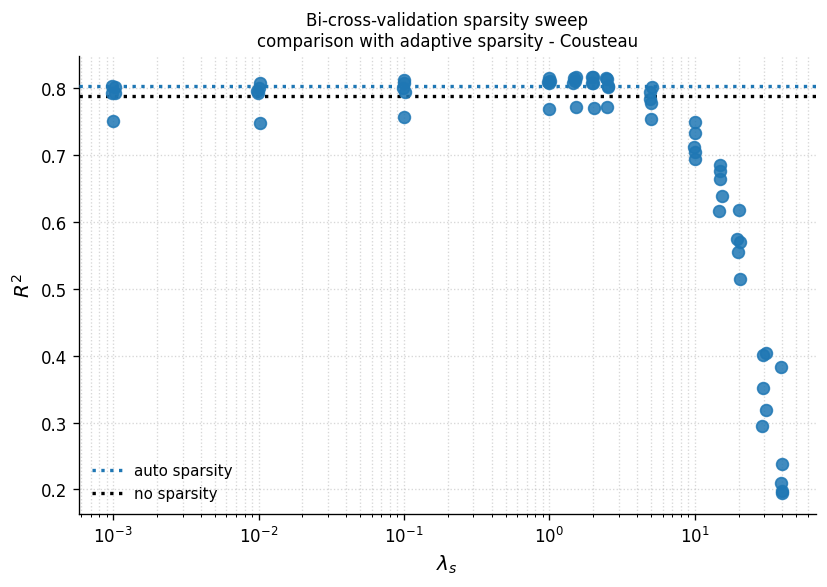

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

# ── Baselines ──────────────────────────────────────────────────────────────
ax.axhline(np.mean(adaptive_r2),  color="#1f77b4", linestyle=":", linewidth=2,
           label="auto sparsity", zorder=3)
ax.axhline(np.mean(no_sparse_r2), color="black",   linestyle=":", linewidth=2,
           label="no sparsity",   zorder=3)

# ── Fixed-λ scatter: one dot per neuron-fold ───────────────────────────────
for lam, fold_means in sweep_results.items():
    if not fold_means:
        continue
    # small x-jitter so overlapping dots are visible
    jitter = np.random.uniform(0.97, 1.03, len(fold_means))
    ax.scatter(np.array([lam] * len(fold_means)) * jitter,
               fold_means,
               color="#1f77b4", s=50, alpha=0.85, zorder=4)

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda_s$", fontsize=12)
ax.set_ylabel(r"$R^2$",       fontsize=12)
ax.set_title(
    "Bi-cross-validation sparsity sweep\n"
    "comparison with adaptive sparsity - Cousteau",
    fontsize=10,
)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("./results/Cousteau/bcv_sparsity_sweep.pdf", bbox_inches="tight")
plt.show()

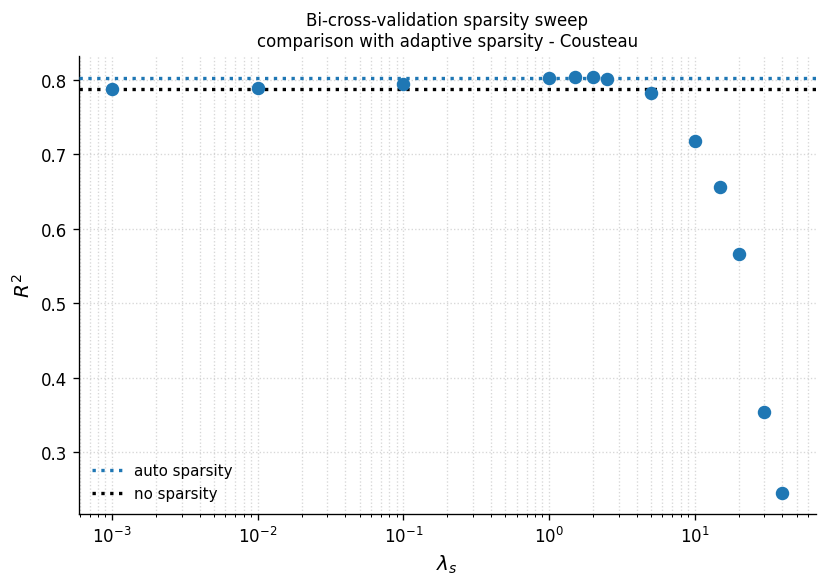

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

# ── Baselines ──────────────────────────────────────────────────────────────
ax.axhline(np.mean(adaptive_r2),  color="#1f77b4", linestyle=":", linewidth=2,
           label="auto sparsity", zorder=3)
ax.axhline(np.mean(no_sparse_r2), color="black",   linestyle=":", linewidth=2,
           label="no sparsity",   zorder=3)

# ── Fixed-λ scatter: one dot = mean across 5 folds ────────────────────────
lam_vals  = [lam for lam, r2s in sweep_results.items() if r2s]
mean_r2s  = [np.mean(r2s) for lam, r2s in sweep_results.items() if r2s]

ax.scatter(lam_vals, mean_r2s, color="#1f77b4", s=50, zorder=4)

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda_s$", fontsize=12)
ax.set_ylabel(r"$R^2$",       fontsize=12)
ax.set_title(
    "Bi-cross-validation sparsity sweep\n"
    "comparison with adaptive sparsity - Cousteau",
    fontsize=10,
)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("./results/Cousteau/bcv_sparsity_sweep.pdf", bbox_inches="tight")
plt.show()